# V3 empirical study — 1.5-year monthly calibration

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | Modified GBM |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all one model in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
Set `RECOMPUTE = True` in the next cell and Run All. Default loads `payload.json` if the company×regime×model cells are already complete, then rewrites the PDF from that payload.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_modified_gbm as study
RECOMPUTE = False  # True to re-run all calibrations + LSM
payload = study.run_or_load(recompute=RECOMPUTE)
print('cells', len(payload['cells']), 'failures', payload['meta']['failures'])
pdf_path = study.write_pdf(payload)
print('PDF', pdf_path)

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,47.67,1.2488,-0.0854,+10.62,25.9%,1


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,37.08,0.6750,+0.4371,+23.66,26.6%,1


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,51.83,1.7487,+1.2257,+34.67,22.2%,1


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,64.56,3.4810,+1.5419,+44.09,24.2%,1


## 2.2 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,51.94,2.1591,+0.9309,+23.67,23.5%,1


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,45.44,3.1559,+3.1131,+34.56,25.4%,1


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,34.33,1.7907,+1.1260,+20.69,24.0%,1


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,45.88,3.7712,+2.1029,+29.60,24.4%,1


## 2.3 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,41.99,0.3590,+0.0799,+16.83,25.2%,1


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,59.39,0.4056,+0.4025,+50.16,25.7%,1


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,33.44,0.8877,+0.4849,+17.78,25.3%,1


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,40.97,1.7579,+0.6597,+22.12,25.1%,1


## 2.4 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,40.25,1.3199,+0.3297,+12.79,24.9%,1


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,29.48,2.6249,+1.0584,+14.84,25.1%,1


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,47.59,22.5407,+14.2723,+30.06,23.0%,1


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
Modified GBM,54.35,26.3138,+11.3697,+32.76,24.2%,1


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Modified GBM BEST,45.39,45.66,16


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


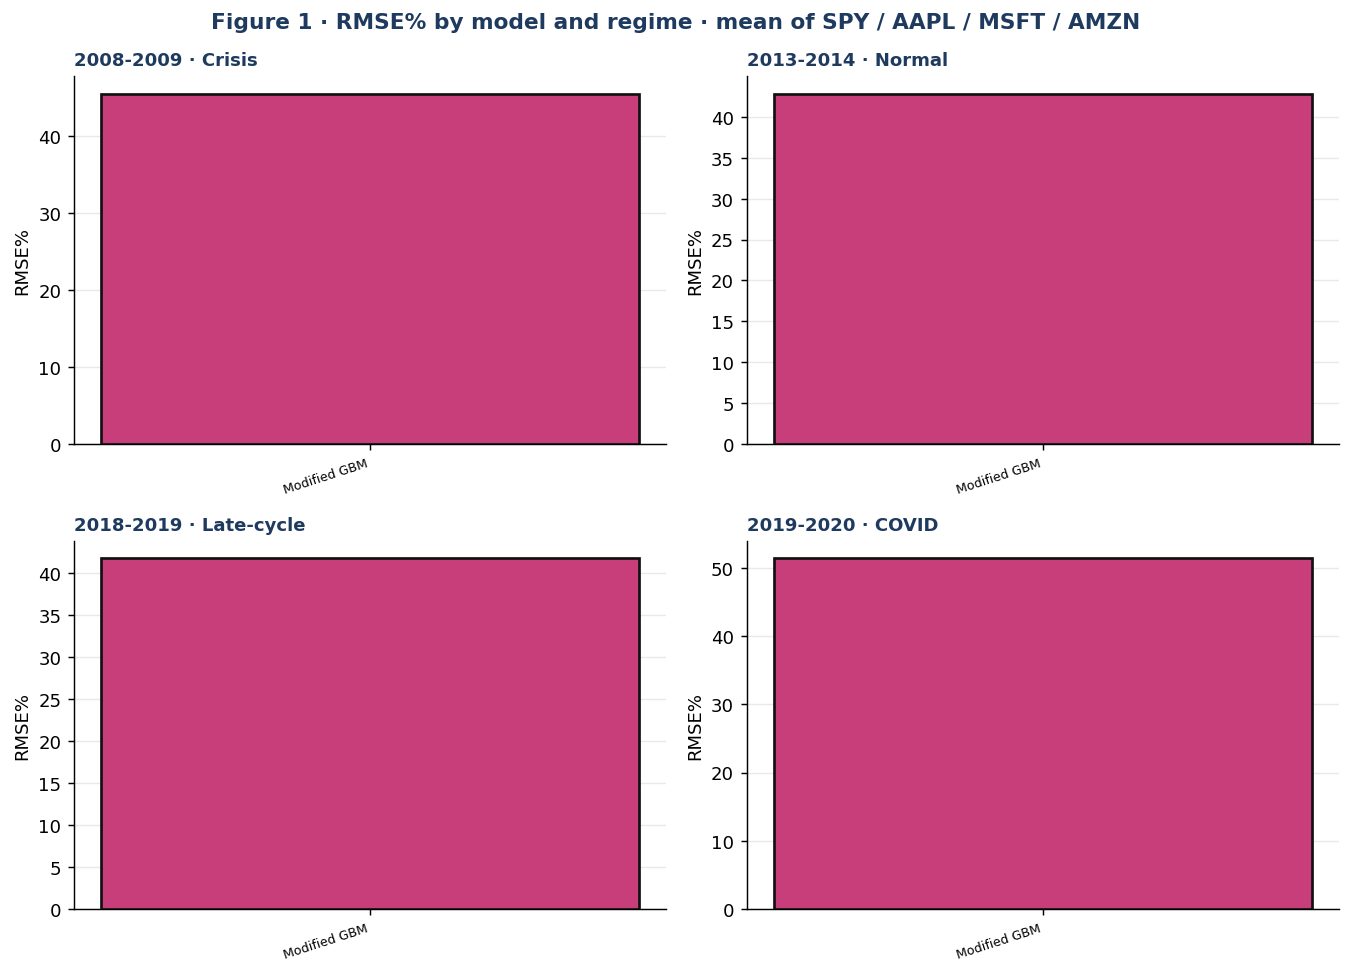

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


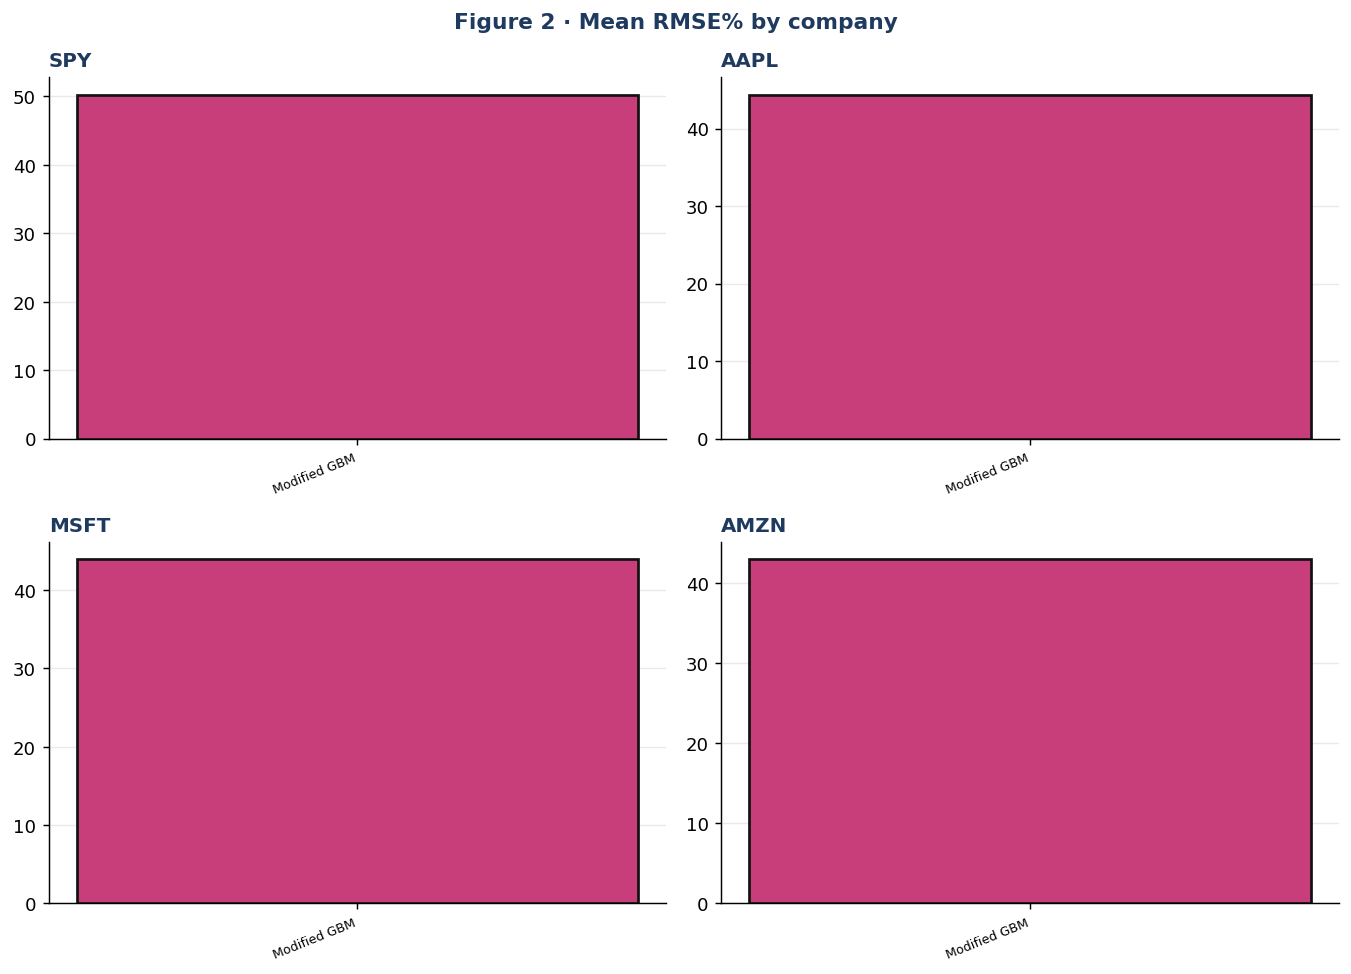

In [1]:
pass

### Figure 3 — Rank heatmap


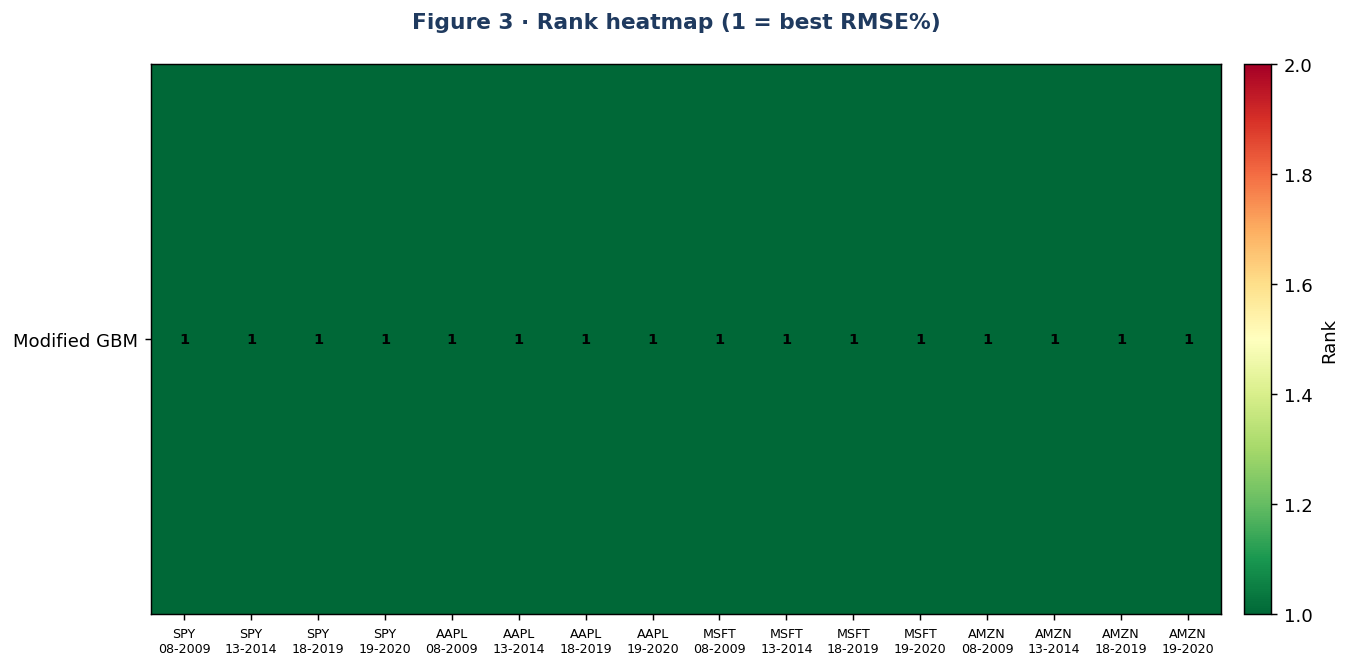

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, Modified GBM is the best overall model (mean RMSE% = 45.39; 16 of 16 cells).

- The ranking is stable: Modified GBM is best in every company and every regime.

- SPY: lowest mean RMSE% is Modified GBM (50.29); wins 4 of 4 regimes.

- AAPL: lowest mean RMSE% is Modified GBM (44.40); wins 4 of 4 regimes.

- MSFT: lowest mean RMSE% is Modified GBM (43.95); wins 4 of 4 regimes.

- AMZN: lowest mean RMSE% is Modified GBM (42.92); wins 4 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Modified GBM (45.46).

- 2013-2014 (Normal): best mean RMSE% is Modified GBM (42.85).

- 2018-2019 (Late-cycle): best mean RMSE% is Modified GBM (41.80).

- 2019-2020 (COVID): best mean RMSE% is Modified GBM (51.44).

- For the overall winner (Modified GBM), crisis RMSE% is 45.46 vs 42.85 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

```python
RECOMPUTE = True
payload = study.run_or_load(recompute=True)
study.write_pdf(payload)
study.build_notebook(payload)
```

Partial results resume from `V3-Models_result/results/empirical_study_1p5y_monthly_10000_modified_gbm/partial/`.
Shared contracts are frozen in `shared_contracts.json` so a resumed run cannot silently change the sample.
